# Color Visualization Notebook -  HSV Test Plots

### Making an HSV Training Plot

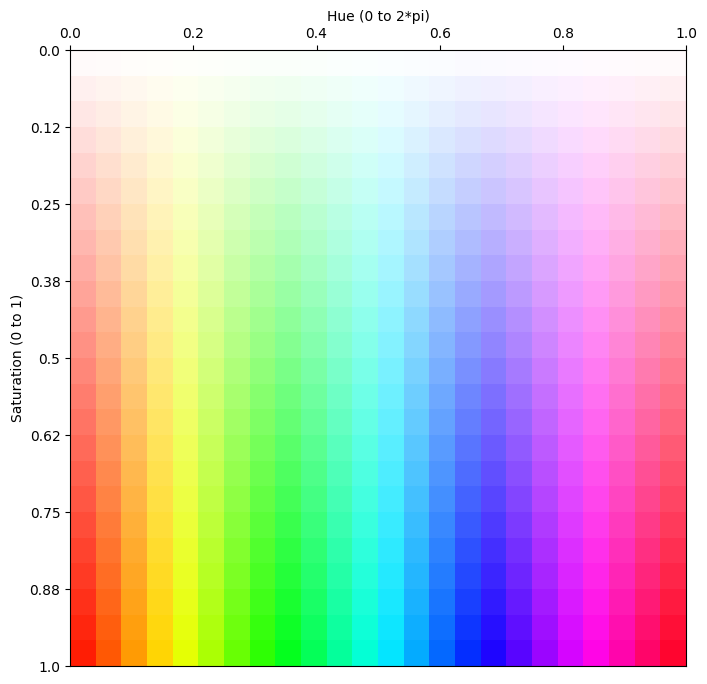

In [94]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Set block size for 30x30 grid
block_size = 24

# Create an HSV image with original size
img_hsv = np.zeros((256, 256, 3), dtype=np.uint8)

# Generate Hue and Saturation gradients
for x in range(256):
    for y in range(256):
        hue = int(x * 179 / 255)  # Scale x to 0-179 for hue
        img_hsv[y, x] = (hue, y, 255)  # Set Hue and Saturation
        img_hsv[y, x] = (hue, 255 - y, 255)  # Set Hue and Saturation


# Resize the HSV image to 30x30 blocks
img_hsv_small = cv2.resize(img_hsv, (block_size, block_size), interpolation=cv2.INTER_AREA)

# Convert to RGB for display
img_rgb_small = cv2.cvtColor(img_hsv_small, cv2.COLOR_HSV2RGB)

# Display the discretized image
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb_small, extent=(0, 1, 0, 1), origin='lower')  # Set origin='lower'

# Configure plot labels and ticks
plt.xlabel('Hue (0 to 2*pi)')
plt.ylabel('Saturation (0 to 1)')
plt.gca().xaxis.set_label_position('top')

# Set x and y ticks with finer intervals for more tick marks
num_ticks = 9  # Number of ticks for finer detail
#tick_values = np.linspace(0, 2*np.pi, num_ticks)
#plt.xticks(tick_values, np.round(tick_values, 2))
tick_values = np.linspace(0, 1, num_ticks)
plt.yticks(tick_values, np.round(1-tick_values, 2))

# Set tick parameters for appearance
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

plt.show()


## Making an HSV Test Plot

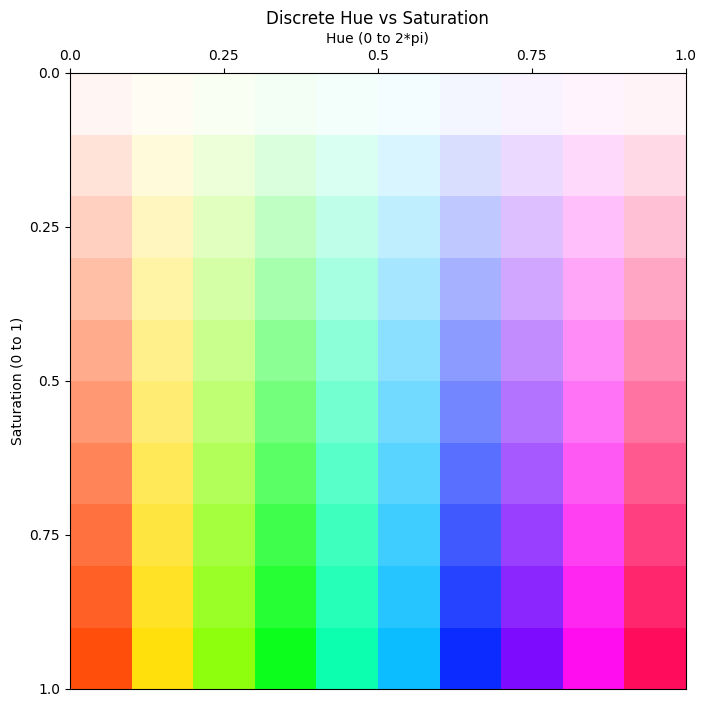

In [95]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Set block size for 30x30 grid
block_size = 10

# Create an HSV image with original size
img_hsv = np.zeros((256, 256, 3), dtype=np.uint8)

# Generate Hue and Saturation gradients
for x in range(256):
    for y in range(256):
        hue = int(x * 179 / 255)  # Scale x to 0-179 for hue
        img_hsv[y, x] = (hue, y, 255)  # Set Hue and Saturation
        img_hsv[y, x] = (hue, 255 - y, 255)  # Set Hue and Saturation


# Resize the HSV image to 30x30 blocks
img_hsv_small = cv2.resize(img_hsv, (block_size, block_size), interpolation=cv2.INTER_AREA)

# Convert to RGB for display
img_rgb_small = cv2.cvtColor(img_hsv_small, cv2.COLOR_HSV2RGB)

# Display the discretized image
plt.figure(figsize=(8, 8))
plt.title('Discrete Hue vs Saturation')
plt.imshow(img_rgb_small, extent=(0, 1, 0, 1), origin='lower')  # Set origin='lower'

# Configure plot labels and ticks
plt.xlabel('Hue (0 to 2*pi)')
plt.ylabel('Saturation (0 to 1)')
plt.gca().xaxis.set_label_position('top')

# Set x and y ticks with finer intervals for more tick marks
num_ticks = 5  # Number of ticks for finer detail
tick_values = np.linspace(0, 1, num_ticks)
plt.xticks(tick_values, np.round(tick_values, 2))
tick_values = np.linspace(0, 1, num_ticks)
plt.yticks(tick_values, np.round(1-tick_values, 2))

# Set tick parameters for appearance
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

plt.show()


### Vortex in HSV

hue represents angle.  
saturation represents magnitude.  
value set to 1.

Text(0.5, 1.0, ' Fixed Vortex')

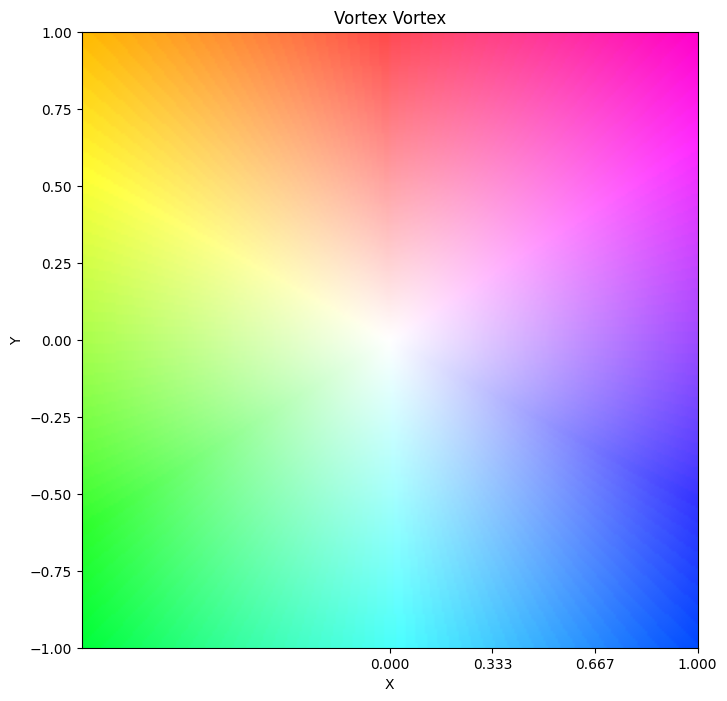

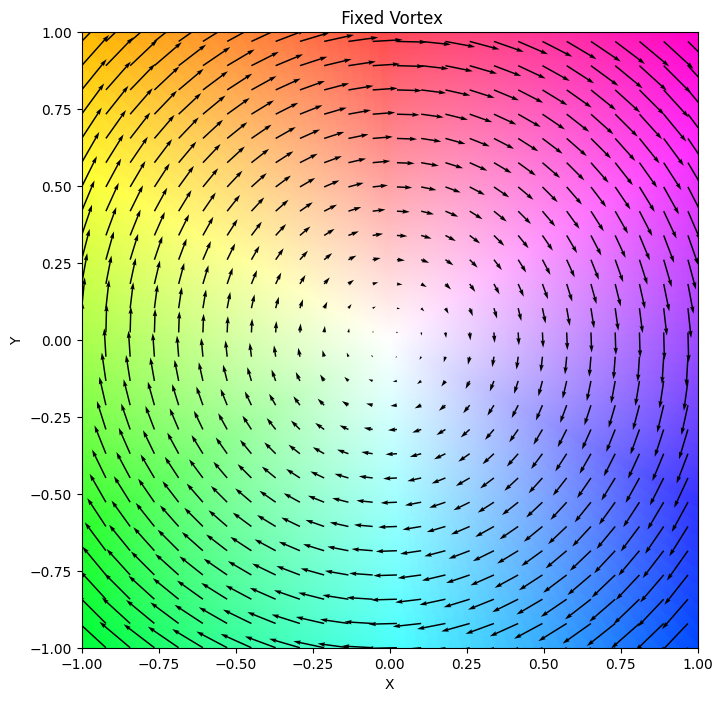

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Define Helper Functions

def vortex_vector_field(x, y, center_x, center_y):
    # Calculate radius and angle
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2) + 1e-8  # small epsilon to prevent divide-by-zero
    theta = np.arctan2(y - center_y, x - center_x)
    
    # Adjusting field components to create a "spinning plate" effect
    u = -r * np.sin(theta) 
    v = r * np.cos(theta) 
    return u, v

def calculate_magnitude_direction(u, v):
    # Calculate magnitude and direction
    magnitude = np.sqrt(u**2 + v**2)  # Magnitude
    direction = (np.arctan2(v, u) + np.pi) / (2 * np.pi)  # Normalize direction to 0-1
    return magnitude, direction


# Create a grid of points
image_pts = 255
x, y = np.meshgrid(np.linspace(-1, 1, image_pts), np.linspace(-1, 1, image_pts))

# Calculate the vector field and magnitude and direction at each point
center_x, center_y = 0.0, 0.0
u, v = vortex_vector_field(x, y, center_x, center_y)
magnitude, direction = calculate_magnitude_direction(u, v)

offset = 0.3
magnitude_normalized = ((magnitude - np.min(magnitude)) / (np.max(magnitude) - np.min(magnitude)) * 255).astype(np.uint8)
magnitude_scaled = (magnitude_normalized*0.7 + offset).astype(np.uint8)
direction_scaled = np.clip(direction * 179, 0, 179).astype(np.uint8)

# Create an HSV image
img_hsv = np.zeros((image_pts, image_pts, 3), dtype=np.uint8)
img_hsv[:, :, 0] = direction_scaled  # Hue channel represents direction
img_hsv[:, :, 1] = magnitude_normalized  # Saturation channel represents magnitude
img_hsv[:, :, 2] = 255  # Set Value to maximum

img_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)



# Display the discretized image
plt.figure(figsize=(8, 8))
plt.title('Discrete Hue vs Saturation')
plt.imshow(img_rgb, origin='lower', extent=[-1, 1, -1, 1])
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vortex Vortex')
plt.xticks([0, 1/3, 2/3, 1]) 

# Plot the quiver plot

max_val = 1  # Adjust as needed
u_clipped = np.clip(magnitude * np.cos(direction * 2 * np.pi), -max_val, max_val)  # Use magnitude and direction
v_clipped = np.clip(magnitude * np.sin(direction * 2 * np.pi), -max_val, max_val)  # Use magnitude and direction
skip = 10
X_downsampled = x[::skip, ::skip]
Y_downsampled = y[::skip, ::skip]
u_clipped_downsampled = u_clipped[::skip, ::skip]
v_clipped_downsampled = v_clipped[::skip, ::skip]

plt.figure(figsize=(8, 8))
plt.quiver(X_downsampled, Y_downsampled, u_clipped_downsampled, v_clipped_downsampled, scale=20, color='black')
plt.title('Discrete Hue vs Saturation')
plt.imshow(img_rgb, origin='lower', extent=[-1, 1, -1, 1])
plt.xlabel('X')
plt.ylabel('Y')
plt.title(' Fixed Vortex')


## Range limited -  from 0.3 - 1 in saturation.

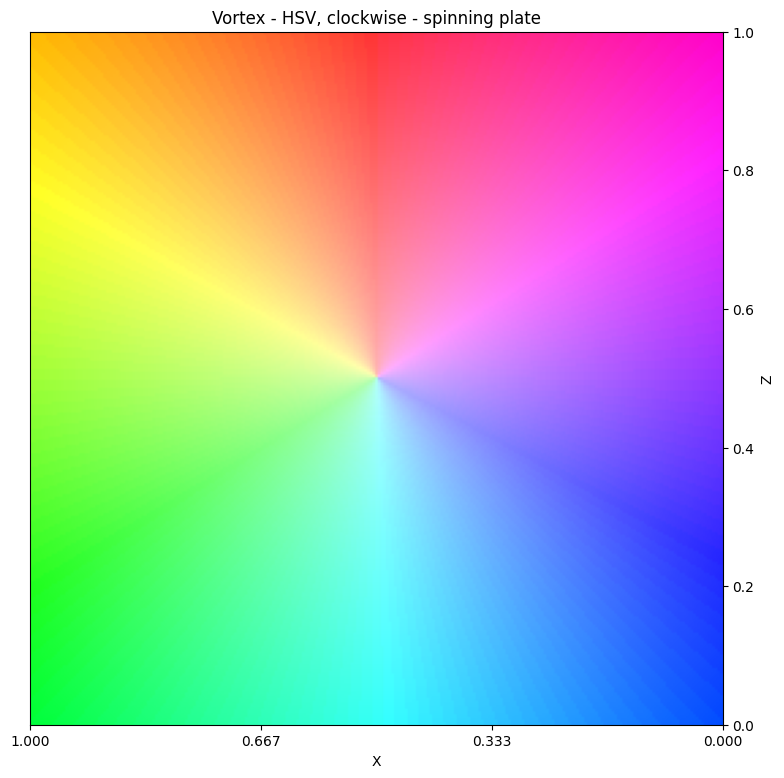

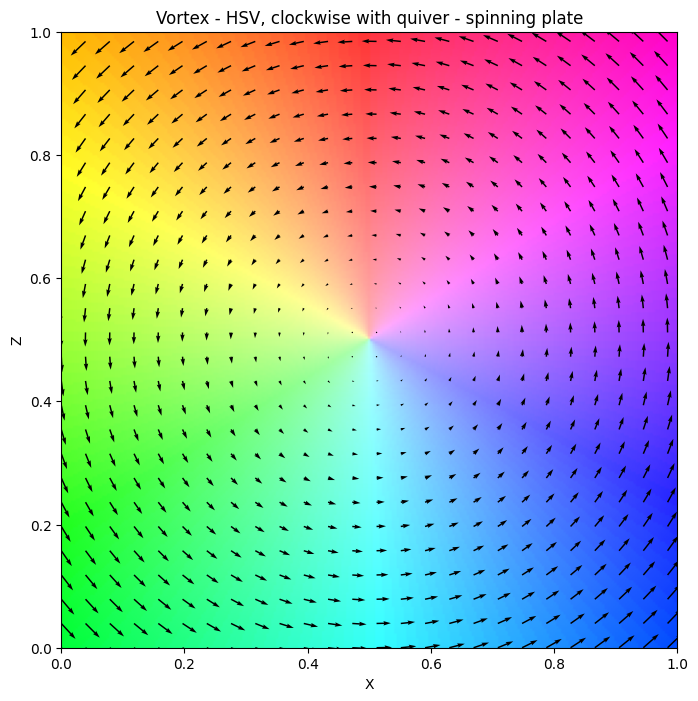

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Define Helper Functions

def vortex_vector_field(x, y, center_x, center_y):
    # Calculate radius and angle
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2) + 1e-8  # small epsilon to prevent divide-by-zero
    theta = np.arctan2(y - center_y, x - center_x)
    
    # Adjusting field components to create a "spinning plate" effect
    u = -r * np.sin(theta) #/ r
    v = r * np.cos(theta) #/ r
    return u, v

def calculate_magnitude_direction(u, v):
    # Calculate magnitude and direction
    magnitude = np.sqrt(u**2 + v**2)  # Magnitude
    direction = (np.arctan2(v, u) + np.pi) / (2 * np.pi)  # Normalize direction to 0-1
    return magnitude, direction


# Create a grid of points
image_pts = 255
x, y = np.meshgrid(np.linspace(0, 1, image_pts), np.linspace(0, 1, image_pts))

# Calculate the vector field and magnitude and direction at each point
center_x, center_y = 0.501, 0.502
u, v = vortex_vector_field(x, y, center_x, center_y)
magnitude, direction = calculate_magnitude_direction(u, v)

offset = 0.3
magnitude_normalized = ((magnitude - np.min(magnitude)) / (np.max(magnitude) - np.min(magnitude)) * 255).astype(np.uint8)
magnitude_scaled = (((magnitude_normalized/255)*(1-offset) + offset)*255).astype(np.uint8)
direction_scaled = np.clip(direction * 179, 0, 179).astype(np.uint8)

# Create an HSV image
img_hsv = np.zeros((image_pts, image_pts, 3), dtype=np.uint8)
img_hsv[:, :, 0] = direction_scaled  # Hue channel represents direction
img_hsv[:, :, 1] =  magnitude_scaled # Saturation channel represents magnitude
img_hsv[:, :, 2] = 255  # Set Value to maximum

img_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)



# Display the resulting image
plt.figure(figsize=(9, 9))
plt.title('Discrete Hue vs Saturation')
plt.xlabel('X')
plt.ylabel('Z')
plt.title('Vortex - HSV, counter-clockwise - spinning plate')
plt.gca().yaxis.set_label_position('right')
plt.gca().xaxis.set_label_position('bottom')
plt.tick_params(left=False, labelleft=False, right=True, labelright=True)
plt.gca().invert_xaxis() 
plt.imshow(img_rgb, origin='lower', extent=[1, 0, 0, 1])
plt.xticks([0, 1/3, 2/3, 1]) 






# Plot the quiver plot
# Invert the x-axis
max_val = 2  # Adjust as needed
u_clipped = np.clip(magnitude * np.cos(direction * 2 * np.pi), -max_val, max_val)  # Use magnitude and direction
v_clipped = np.clip(magnitude * np.sin(direction * 2 * np.pi), -max_val, max_val)  # Use magnitude and direction
skip = 10
X_downsampled = x[::skip, ::skip]
Y_downsampled = y[::skip, ::skip]
u_clipped_downsampled = u_clipped[::skip, ::skip]
v_clipped_downsampled = v_clipped[::skip, ::skip]

plt.figure(figsize=(8, 8))

plt.quiver(X_downsampled, Y_downsampled, -u_clipped_downsampled, -v_clipped_downsampled, scale=20, color='black')
plt.title('Discrete Hue vs Saturation')
plt.xlabel('X')
plt.ylabel('Z')
plt.title('Vortex - HSV, counter-clockwise with quiver - spinning plate')
# Invert the x-axis
plt.imshow(img_rgb, origin='lower', extent=[0, 1, 0, 1])





## Saturation Racer

(0.2, 1.0)

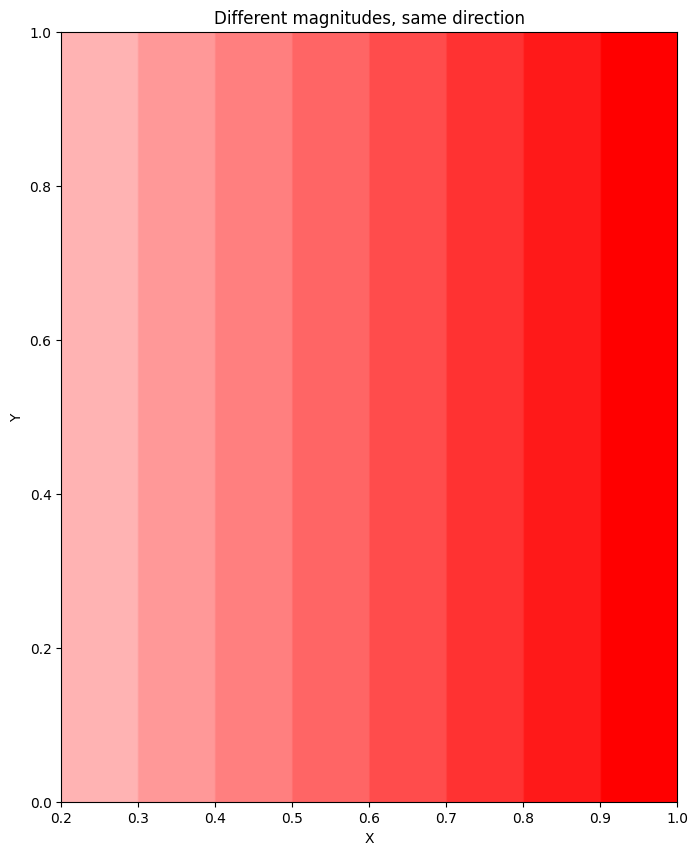

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Define Helper Functions




# Create a grid of points
image_pts = 300
x, y = np.meshgrid(np.linspace(0, 1, image_pts), np.linspace(0, 1, image_pts))

values = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
magnitude_gradient = np.tile(np.repeat(values, 30), (image_pts, 1))

 

# Create an HSV image
img_hsv = np.zeros((image_pts, image_pts, 3), dtype=np.uint8)
img_hsv[:, :, 0] = 0  # Hue channel represents direction
img_hsv[:, :, 1] = img_hsv[:, :, 1] = (magnitude_gradient * 255) #.astype(np.uint8) # Saturation channel represents magnitude
img_hsv[:, :, 2] = 255  # Set Value to maximum

img_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)



# Display the discretized image
plt.figure(figsize=(12, 10))
plt.title('Discrete Hue vs Saturation')
plt.imshow(img_rgb, origin='lower', extent=[0, 1, 0, 1])
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Different magnitudes, same direction')
plt.xlim(0.2, 1)



# Sinking Vortex w/ 0.3 in middle

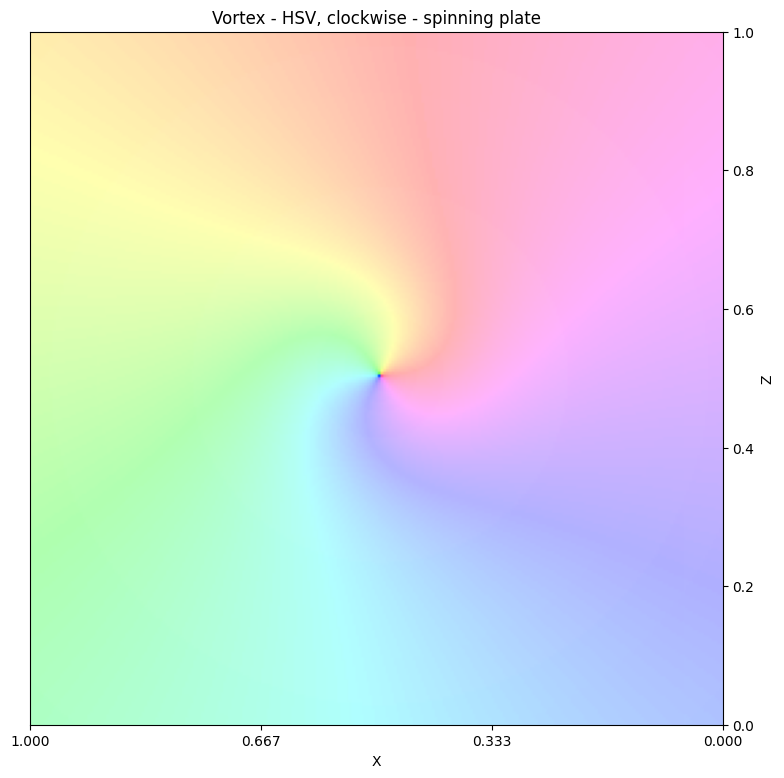

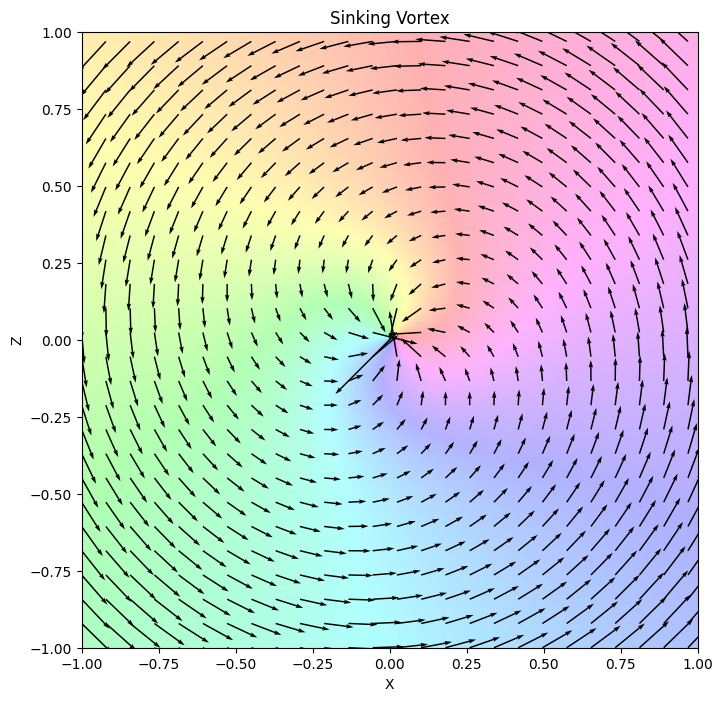

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Define Helper Functions

def vortex_vector_field(x, y, center_x, center_y):
    # Calculate radius and angle
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2) + 1e-5  # small epsilon to prevent divide-by-zero
    theta = np.arctan2(y - center_y, x - center_x)
    
    # Adjusting field components to create a "spinning plate" effect
    u = -r * np.sin(theta) #/ r
    v = r * np.cos(theta) #/ r

    # Calculating A sink
    x_centre = x - center_x
    y_centre = y - center_y
    r2 = np.sqrt(x_centre**2 + y_centre**2)
    r2 = np.where(r == 0, 1e-6, r2)

    # spring source
    u1 = -x_centre / r2**2
    v1 = -y_centre / r2**2

    u = u + 0.1*u1
    v = v + 0.1*v1
    return u, v

def calculate_magnitude_direction(u, v):
    # Calculate magnitude and direction
    magnitude = np.sqrt(u**2 + v**2)  # Magnitude
    direction = (np.arctan2(v, u) + np.pi) / (2 * np.pi)  # Normalize direction to 0-1
    return magnitude, direction


# Create a grid of points
image_pts = 255
x, y = np.meshgrid(np.linspace(-1, 1, image_pts), np.linspace(-1, 1, image_pts))

# Calculate the vector field and magnitude and direction at each point
center_x, center_y = 0.01, 0.01
u, v = vortex_vector_field(x, y, center_x, center_y)
magnitude, direction = calculate_magnitude_direction(u, v)

offset = 0.3
magnitude_normalized = ((magnitude - np.min(magnitude)) / (np.max(magnitude) - np.min(magnitude)) * 255).astype(np.uint8)
magnitude_scaled = (((magnitude_normalized/255)*(1-offset) + offset)*255).astype(np.uint8)
direction_scaled = np.clip(direction * 179, 0, 179).astype(np.uint8)

# Create an HSV image
img_hsv = np.zeros((image_pts, image_pts, 3), dtype=np.uint8)
img_hsv[:, :, 0] = direction_scaled  # Hue channel represents direction
img_hsv[:, :, 1] =  magnitude_scaled # Saturation channel represents magnitude
img_hsv[:, :, 2] = 255  # Set Value to maximum

img_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)



# Display the resulting image
plt.figure(figsize=(9, 9))
plt.title('Sinking Vortex')
plt.xlabel('X')
plt.ylabel('Z')
plt.title('Vortex - HSV, clockwise - spinning plate')
plt.gca().yaxis.set_label_position('right')
plt.gca().xaxis.set_label_position('bottom')
plt.tick_params(left=False, labelleft=False, right=True, labelright=True)
plt.gca().invert_xaxis() 
plt.imshow(img_rgb, origin='lower', extent=[1, 0, 0, 1])
plt.xticks([0, 1/3, 2/3, 1]) 



# Plot the quiver plot
# Invert the x-axis
max_val = 2  # Adjust as needed
u_clipped = np.clip(magnitude * np.cos(direction * 2 * np.pi), -max_val, max_val)  # Use magnitude and direction
v_clipped = np.clip(magnitude * np.sin(direction * 2 * np.pi), -max_val, max_val)  # Use magnitude and direction
skip = 10
X_downsampled = x[::skip, ::skip]
Y_downsampled = y[::skip, ::skip]
u_clipped_downsampled = u_clipped[::skip, ::skip]
v_clipped_downsampled = v_clipped[::skip, ::skip]

plt.figure(figsize=(8, 8))

plt.quiver(X_downsampled, Y_downsampled, -u_clipped_downsampled, -v_clipped_downsampled, scale=20, color='black')
plt.title('Discrete Hue vs Saturation')
plt.xlabel('X')
plt.ylabel('Z')
plt.title('Sinking Vortex')
# Invert the x-axis
plt.imshow(img_rgb, origin='lower', extent=[-1, 1, -1, 1])





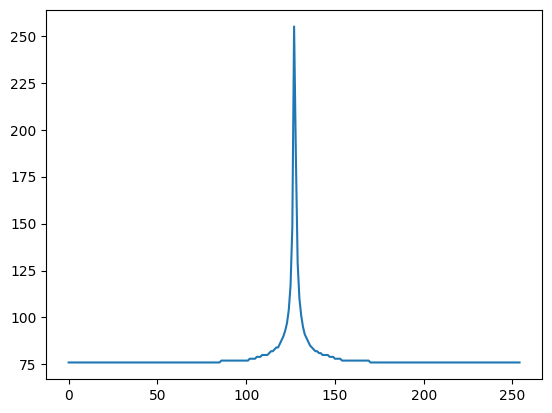

In [85]:
plt.plot(magnitude_scaled[:][128])


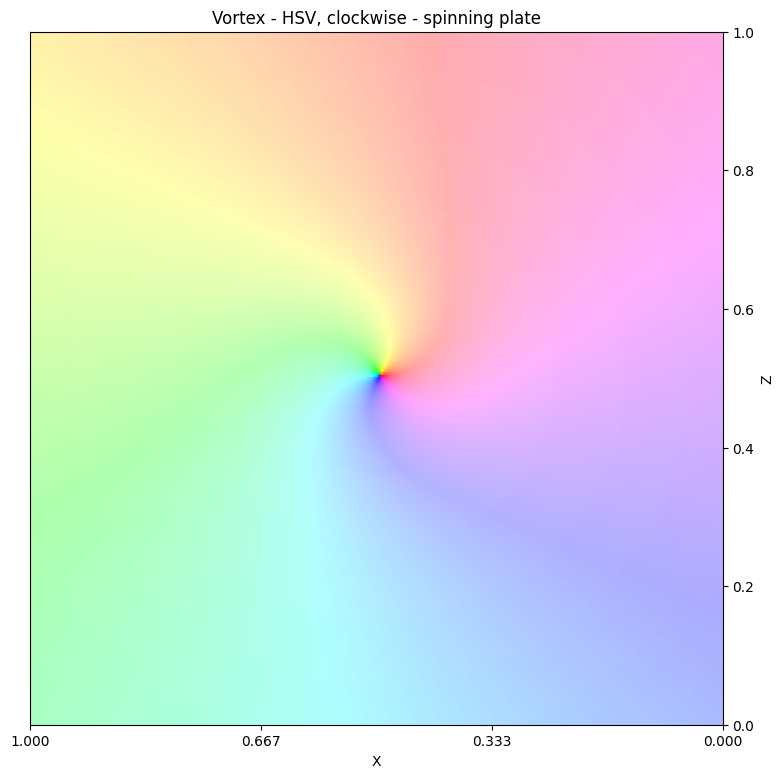

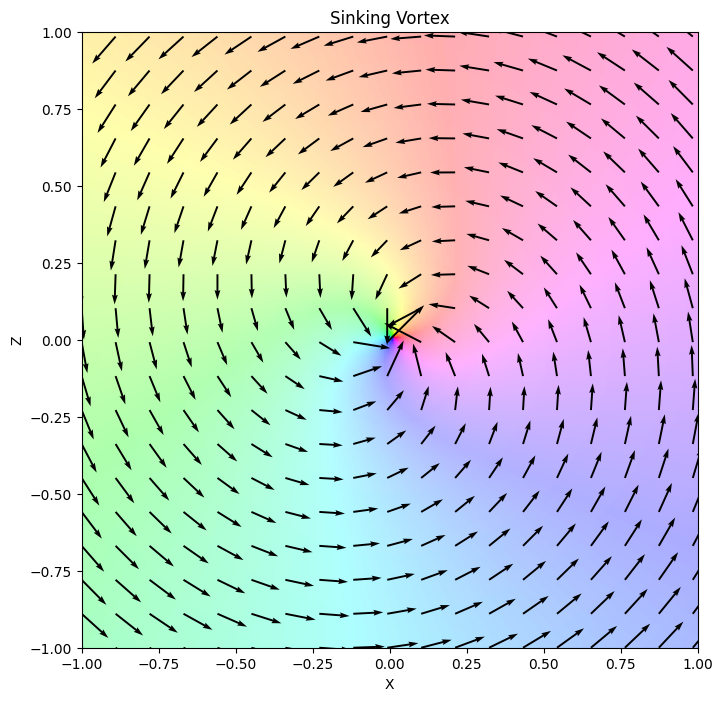

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Define Helper Functions

def vortex_vector_field(x, y, center_x, center_y):
    # Calculate radius and angle
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2) + 6*1e-3  # small epsilon to prevent divide-by-zero
    theta = np.arctan2(y - center_y, x - center_x)
    
    # Adjusting field components to create a "spinning plate" effect
    u = -np.sqrt(r) * np.sin(theta) #/ r
    v = np.sqrt(r) * np.cos(theta) #/ r

    # Calculating A sink
    x_centre = x - center_x
    y_centre = y - center_y
    r2 = np.sqrt(x_centre**2 + y_centre**2) + 5*1e-3

    # spring source
    u1 = -x_centre / r2**2
    v1 = -y_centre / r2**2

    u = u + 0.17*u1
    v = v + 0.17*v1
    return u, v

def calculate_magnitude_direction(u, v):
    # Calculate magnitude and direction
    magnitude = np.sqrt(u**2 + v**2)  # Magnitude
    direction = (np.arctan2(v, u) + np.pi) / (2 * np.pi)  # Normalize direction to 0-1
    return magnitude, direction


# Create a grid of points
image_pts = 255
x, y = np.meshgrid(np.linspace(-1, 1, image_pts), np.linspace(-1, 1, image_pts))

# Calculate the vector field and magnitude and direction at each point
center_x, center_y = 0.01, 0.01
u, v = vortex_vector_field(x, y, center_x, center_y)
magnitude, direction = calculate_magnitude_direction(u, v)

offset = 0.3
magnitude_normalized = ((magnitude - np.min(magnitude)) / (np.max(magnitude) - np.min(magnitude)) * 255).astype(np.uint8)
magnitude_scaled = (((magnitude_normalized/255)*(1-offset) + offset)*255).astype(np.uint8)
direction_scaled = np.clip(direction * 179, 0, 179).astype(np.uint8)

# Create an HSV image
img_hsv = np.zeros((image_pts, image_pts, 3), dtype=np.uint8)
img_hsv[:, :, 0] = direction_scaled  # Hue channel represents direction
img_hsv[:, :, 1] =  magnitude_scaled # Saturation channel represents magnitude
img_hsv[:, :, 2] = 255  # Set Value to maximum

img_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)



# Display the resulting image
plt.figure(figsize=(9, 9))
plt.title('Discrete Hue vs Saturation')
plt.xlabel('X')
plt.ylabel('Z')
plt.title('Vortex - HSV, clockwise - spinning plate')
plt.gca().yaxis.set_label_position('right')
plt.gca().xaxis.set_label_position('bottom')
plt.tick_params(left=False, labelleft=False, right=True, labelright=True)
plt.gca().invert_xaxis() 
plt.imshow(img_rgb, origin='lower', extent=[1, 0, 0, 1])
plt.xticks([0, 1/3, 2/3, 1]) 



# Plot the quiver plot
# Invert the x-axis
max_val = 1.2  # Adjust as needed
u_clipped = np.clip(magnitude * np.cos(direction * 2 * np.pi), -max_val, max_val)  # Use magnitude and direction
v_clipped = np.clip(magnitude * np.sin(direction * 2 * np.pi), -max_val, max_val)  # Use magnitude and direction
skip = 14
X_downsampled = x[::skip, ::skip]
Y_downsampled = y[::skip, ::skip]
u_clipped_downsampled = u_clipped[::skip, ::skip]
v_clipped_downsampled = v_clipped[::skip, ::skip]

plt.figure(figsize=(8, 8))

plt.quiver(X_downsampled, Y_downsampled, -u_clipped_downsampled, -v_clipped_downsampled, scale=20, color='black')
plt.title('Discrete Hue vs Saturation')
plt.xlabel('X')
plt.ylabel('Z')
plt.title('Sinking Vortex')
# Invert the x-axis
plt.imshow(img_rgb, origin='lower', extent=[-1, 1,-1, 1])





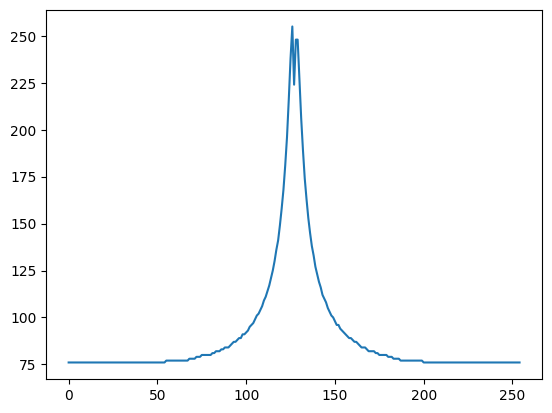

In [90]:
plt.plot(magnitude_scaled[:][128])


## Scaled

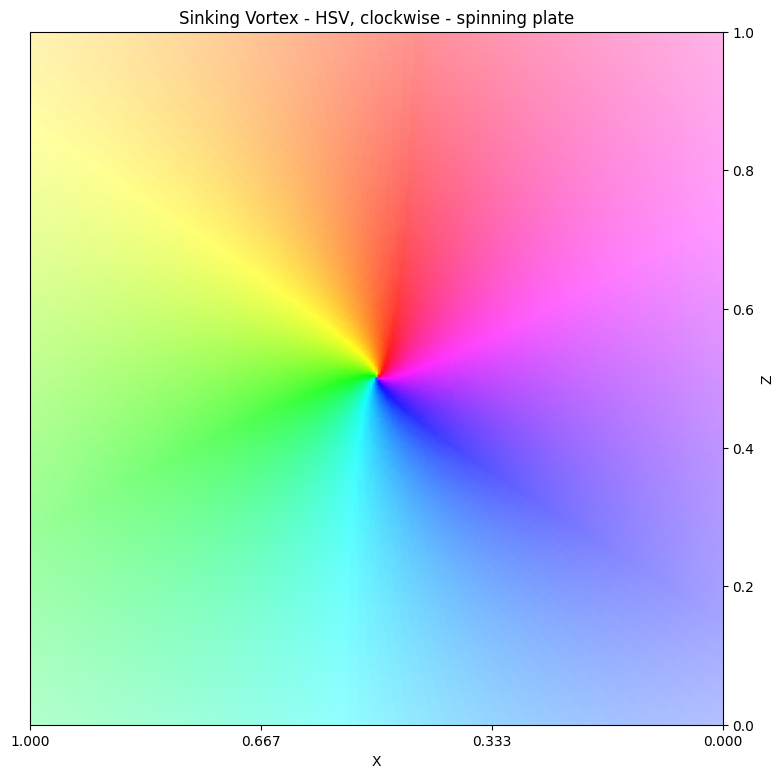

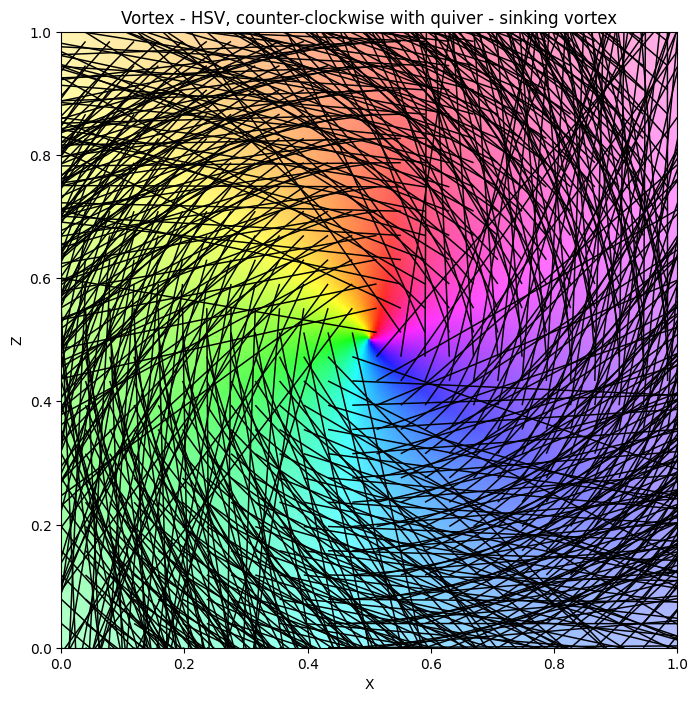

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Define Helper Functions

def vortex_vector_field(x, y, center_x, center_y):
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2) + 1e-5
    theta = np.arctan2(y - center_y, x - center_x)
    
    # Add dampening to prevent excessive scaling
    u = -np.sqrt(r) * np.sin(theta)
    v = np.sqrt(r)  * np.cos(theta)
    
    # Calculate center-relative coordinates
    x_centre = x - center_x
    y_centre = y - center_y
    r2 = np.sqrt(x_centre**2 + y_centre**2)
    r2 = np.where(r == 0, 1e-5, r2)
    
    # Reduce inward strength to balance with r-scaling
    strength = 0.1  # Reduced from 0.5
    u1 = -strength * x_centre / r2
    v1 = -strength * y_centre / r2
    
    return u + u1, v + v1

def calculate_magnitude_direction(u, v):
    # Calculate magnitude and direction
    magnitude = np.sqrt(u**2 + v**2)  # Magnitude
    direction = (np.arctan2(v, u) + np.pi) / (2 * np.pi)  # Normalize direction to 0-1
    return magnitude, direction


# Create a grid of points
image_pts = 255
x, y = np.meshgrid(np.linspace(0, 1, image_pts), np.linspace(0, 1, image_pts))

# Calculate the vector field and magnitude and direction at each point
center_x, center_y = 0.501, 0.502
u, v = vortex_vector_field(x, y, center_x, center_y)
magnitude, direction = calculate_magnitude_direction(u, v)

offset = 0.3
magnitude_normalized = 255 - ((magnitude - np.min(magnitude)) / (np.max(magnitude) - np.min(magnitude)) * 255)
magnitude_normalized = (magnitude_normalized ).astype(np.uint8)
magnitude_scaled = (((magnitude_normalized/255)*(1-offset) + offset)*255).astype(np.uint8)
direction_scaled = np.clip(direction * 179, 0, 179).astype(np.uint8)

# Create an HSV image
img_hsv = np.zeros((image_pts, image_pts, 3), dtype=np.uint8)
img_hsv[:, :, 0] = direction_scaled  # Hue channel represents direction
img_hsv[:, :, 1] =  magnitude_scaled # Saturation channel represents magnitude
img_hsv[:, :, 2] = 255  # Set Value to maximum

img_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)



# Display the resulting image
plt.figure(figsize=(9, 9))
plt.title('Discrete Hue vs Saturation')
plt.xlabel('X')
plt.ylabel('Z')
plt.title('Sinking Vortex - HSV, clockwise - spinning plate')
plt.gca().yaxis.set_label_position('right')
plt.gca().xaxis.set_label_position('bottom')
plt.tick_params(left=False, labelleft=False, right=True, labelright=True)
plt.gca().invert_xaxis() 
plt.imshow(img_rgb, origin='lower', extent=[1, 0, 0, 1])
plt.xticks([0, 1/3, 2/3, 1]) 



# Plot the quiver plot
# Invert the x-axis
max_val = 200 # Adjust as needed
u_clipped = np.clip(magnitude_scaled * np.cos(direction * 2 * np.pi), -max_val, max_val)  # Use magnitude and direction
v_clipped = np.clip(magnitude_scaled * np.sin(direction * 2 * np.pi), -max_val, max_val)  # Use magnitude and direction
skip = 10
X_downsampled = x[::skip, ::skip]
Y_downsampled = y[::skip, ::skip]
u_clipped_downsampled = u_clipped[::skip, ::skip]
v_clipped_downsampled = v_clipped[::skip, ::skip]

plt.figure(figsize=(8, 8))

plt.quiver(X_downsampled, Y_downsampled, -u_clipped_downsampled, -v_clipped_downsampled, scale=20, color='black')
plt.title('Discrete Hue vs Saturation')
plt.xlabel('X')
plt.ylabel('Z')
plt.title('Vortex - HSV, counter-clockwise with quiver - sinking vortex')
# Invert the x-axis
plt.imshow(img_rgb, origin='lower', extent=[0, 1, 0, 1])





In [115]:
np.min(magnitude_scaled)

76